In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

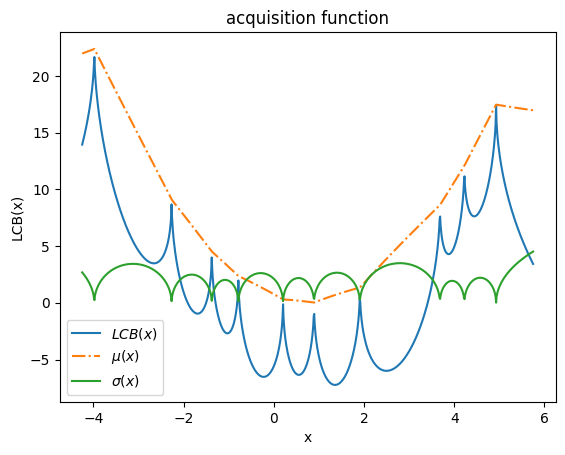

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 50
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)


for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU,l=li,u=ui)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = acqf.evaluate_meansig2(np.atleast_1d(mu_L), np.atleast_1d(s2_U))[0]
        LCB_U = acqf.evaluate_meansig2(np.atleast_1d(mu_U), np.atleast_1d(s2_L))[0]
        #LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        #LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

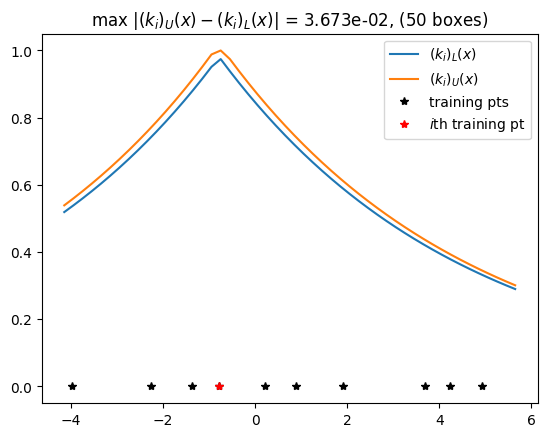

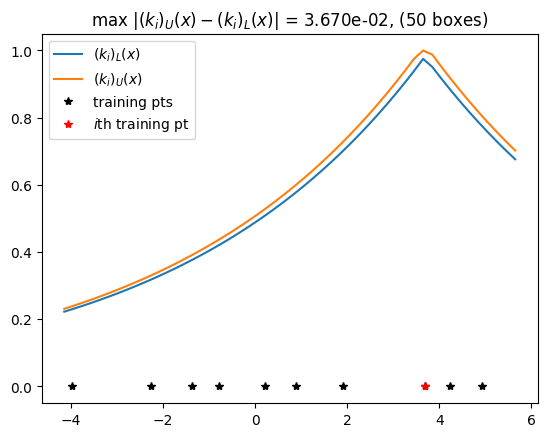

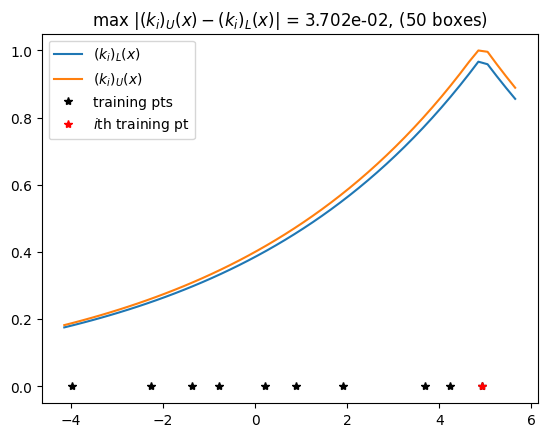

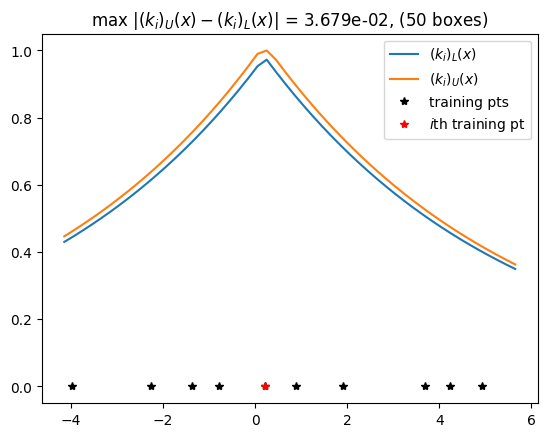

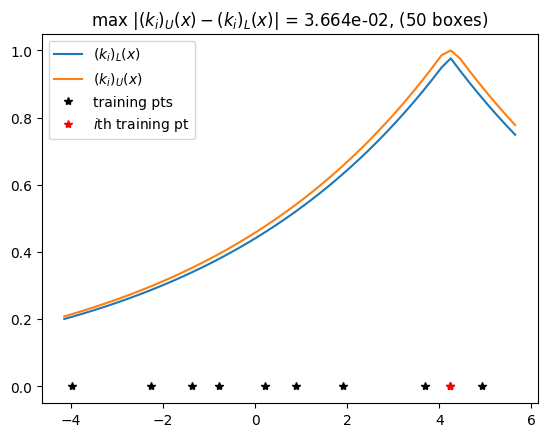

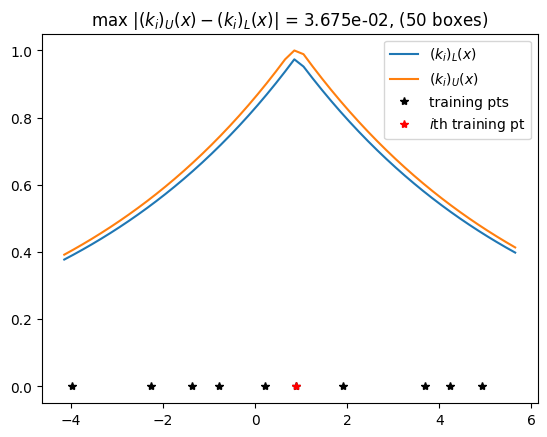

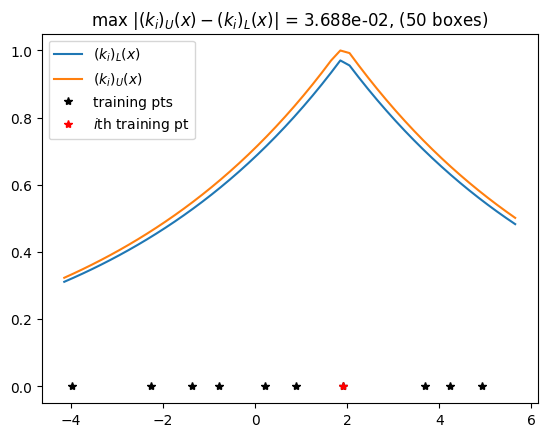

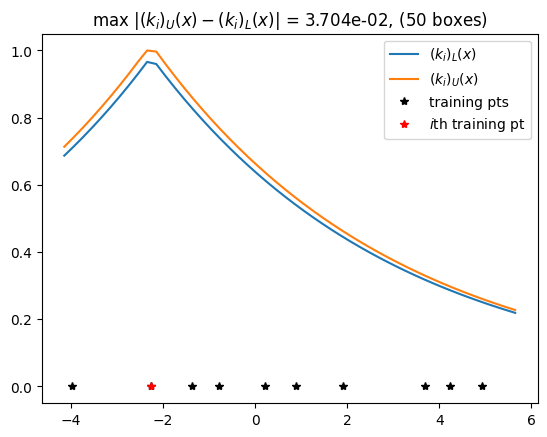

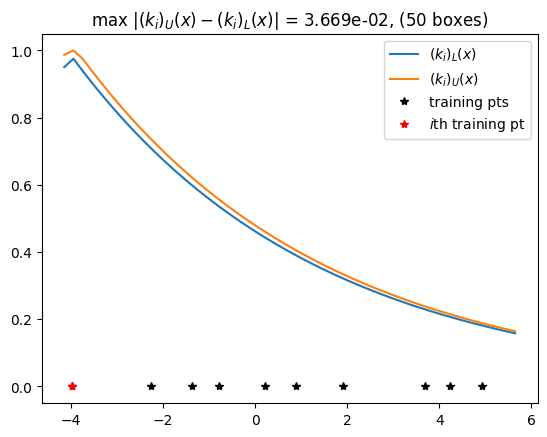

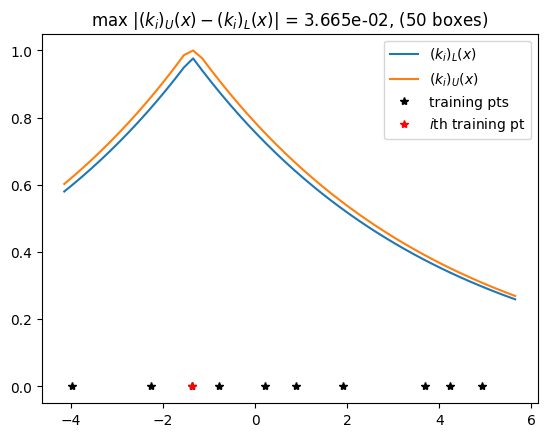

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

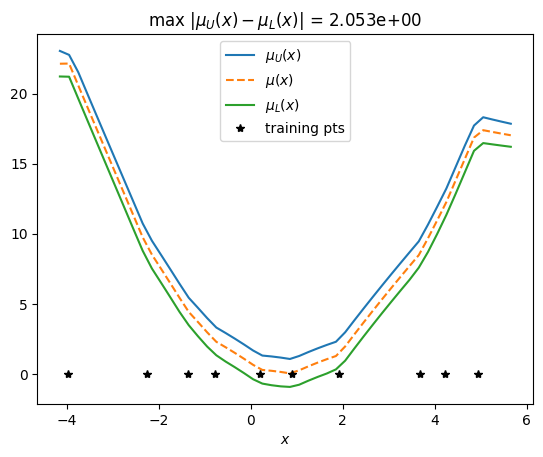

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

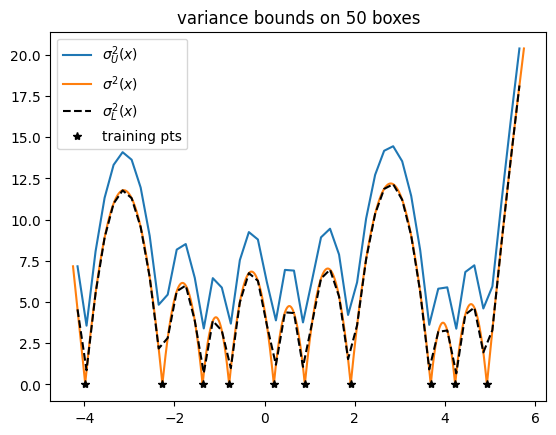

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(X, sigmaX**2., label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, "k--", label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

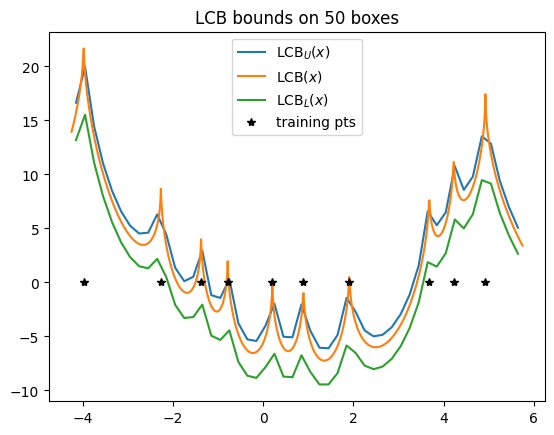

In [8]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [9]:
from hiopbbpy.opt import BnBAlgorithm
bnb = BnBAlgorithm(acqf)
bnb.epsilon_diam = 1.e-12
bnb.epsilon_gap = 1.e-4
bnb.BnB_LBmethod = None
bnb.max_bnbiter = 2000
xstar = bnb.optimize()

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -51.55759043161523
Initial acquisition upper bound: -5.189081699682497

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-51.55759043161523, U=-5.189081699682497
Current best feasible value (LUB): -5.189081699682497
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-34.257741324566574, U=-0.881580876797452
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-34.665279040939524, U=-2.0939713311986177
Queue size: 2 | LB=-34.665279040939524 | LUB=-5.189081699682497 | Gap<=29.476197341257027

--- BnB Iteration 2 ---
Node bounds: l=[0.75], u=[5.75]
Node acquisition bounds: L=-34.665279040939524, U=-2.0939713311986177
Current best feasible value (LUB): -5.189081699682497
  Branching to child: l=[0.75], u=[3.25]
  Child acquisition bounds: L=-25.76038337427

  Child acquisition bounds: L=-7.303704439465876, U=-5.078856256647844
Queue size: 20 | LB=-9.412955476714428 | LUB=-7.235623749317466 | Gap<=2.177331727396962

--- BnB Iteration 23 ---
Node bounds: l=[-1.125], u=[-0.5]
Node acquisition bounds: L=-9.412955476714428, U=-0.0006601787513296209
Current best feasible value (LUB): -7.235623749317466
  Branching to child: l=[-1.125], u=[-0.8125]
  Child acquisition bounds: L=-6.775319933298362, U=-2.5525709814428748
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.8125], u=[-0.5]
  Child acquisition bounds: L=-7.511406755142849, U=-3.2052679187184925
Queue size: 20 | LB=-9.118170992056934 | LUB=-7.235623749317466 | Gap<=1.8825472427394674

--- BnB Iteration 24 ---
Node bounds: l=[2.3125], u=[2.625]
Node acquisition bounds: L=-9.118170992056934, U=-5.992275807540654
Current best feasible value (LUB): -7.235623749317466
  Branching to child: l=[2.3125], u=[2.46875]
  Child acquisition bounds: L=-7.5494694873771175, U=-5.90417813753838

  Child acquisition bounds: L=-7.476896663681458, U=-7.23949581022309
Queue size: 24 | LB=-7.691005417087705 | LUB=-7.240472126488837 | Gap<=0.4505332905988686

--- BnB Iteration 46 ---
Node bounds: l=[1.296875], u=[1.3359375]
Node acquisition bounds: L=-7.691005417087705, U=-7.215100283498941
Current best feasible value (LUB): -7.240472126488837
  Branching to child: l=[1.296875], u=[1.31640625]
  Child acquisition bounds: L=-7.441209984140568, U=-7.201326839639801
  Branching to child: l=[1.31640625], u=[1.3359375]
  Child acquisition bounds: L=-7.4646715630696905, U=-7.225875598577687
Queue size: 25 | LB=-7.69064070439857 | LUB=-7.240472126488837 | Gap<=0.4501685779097331

--- BnB Iteration 47 ---
Node bounds: l=[1.375], u=[1.4140625]
Node acquisition bounds: L=-7.69064070439857, U=-7.219229058883007
Current best feasible value (LUB): -7.240472126488837
  Branching to child: l=[1.375], u=[1.39453125]
  Child acquisition bounds: L=-7.465941593349369, U=-7.228865939119778
  Branching 

  Child acquisition bounds: L=-6.855726693824038, U=-6.379507733033763
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.3046875], u=[-0.265625]
  Child acquisition bounds: L=-6.952327598072493, U=-6.476705863875235
  Child pruned: L ≥ LUB + eps.
Queue size: 26 | LB=-7.365415823388251 | LUB=-7.240472126488837 | Gap<=0.12494369689941465

--- BnB Iteration 71 ---
Node bounds: l=[1.43359375], u=[1.453125]
Node acquisition bounds: L=-7.365415823388251, U=-7.1278634253165025
Current best feasible value (LUB): -7.240472126488837
  Branching to child: l=[1.43359375], u=[1.44335938]
  Child acquisition bounds: L=-7.2592997416605245, U=-7.1402492619760825
  Branching to child: l=[1.44335938], u=[1.453125]
  Child acquisition bounds: L=-7.233934126714304, U=-7.114750688496917
  Child pruned: L ≥ LUB + eps.
Queue size: 26 | LB=-7.359443015685218 | LUB=-7.240472126488837 | Gap<=0.11897088919638144

--- BnB Iteration 72 ---
Node bounds: l=[1.35546875], u=[1.36523438]
Node acquisition bound

  Child acquisition bounds: L=-7.268830855807443, U=-7.238940563296111
  Branching to child: l=[1.34814453], u=[1.35058594]
  Child acquisition bounds: L=-7.269485709413815, U=-7.239606031794297
Queue size: 38 | LB=-7.298527564467868 | LUB=-7.240508872092001 | Gap<=0.05801869237586743

--- BnB Iteration 94 ---
Node bounds: l=[1.23828125], u=[1.2578125]
Node acquisition bounds: L=-7.298527564467868, U=-7.053640091951337
Current best feasible value (LUB): -7.240508872092001
  Branching to child: l=[1.23828125], u=[1.24804688]
  Child acquisition bounds: L=-7.159214626696702, U=-7.036108060757918
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.24804688], u=[1.2578125]
  Child acquisition bounds: L=-7.192904729924812, U=-7.070342901674268
  Child pruned: L ≥ LUB + eps.
Queue size: 37 | LB=-7.2983879612035585 | LUB=-7.240508872092001 | Gap<=0.057879089111557924

--- BnB Iteration 95 ---
Node bounds: l=[1.36523438], u=[1.37011719]
Node acquisition bounds: L=-7.2983879612035585, U=-

...

  Child acquisition bounds: L=-7.2403530825980695, U=-7.240008499836536
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.36283112], u=[1.36286926]
  Child acquisition bounds: L=-7.240346378310012, U=-7.240001807586023
  Child pruned: L ≥ LUB + eps.
Queue size: 460 | LB=-7.240690161664959 | LUB=-7.240511038806906 | Gap<=0.0001791228580527715

--- BnB Iteration 844 ---
Node bounds: l=[1.36035156], u=[1.36038971]
Node acquisition bounds: L=-7.240690161664959, U=-7.24034477859174
Current best feasible value (LUB): -7.240511038806906
  Branching to child: l=[1.36035156], u=[1.36037064]
  Child acquisition bounds: L=-7.240520221135482, U=-7.240345736720107
  Branching to child: l=[1.36037064], u=[1.36038971]
  Child acquisition bounds: L=-7.240518298073158, U=-7.240343817696115
Queue size: 461 | LB=-7.240689607570847 | LUB=-7.240511038806906 | Gap<=0.0001785687639408451

--- BnB Iteration 845 ---
Node bounds: l=[1.34646606], u=[1.34661865]
Node acquisition bounds: L=-7.2406896075708

  Child acquisition bounds: L=-7.240504635212855, U=-7.240328774291675
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.35361862], u=[1.3536377]
  Child acquisition bounds: L=-7.2405066376787515, U=-7.240330780322491
  Child pruned: L ≥ LUB + eps.
Queue size: 379 | LB=-7.240677578486228 | LUB=-7.240511038806906 | Gap<=0.0001665396793217866

--- BnB Iteration 934 ---
Node bounds: l=[1.37866211], u=[1.37927246]
Node acquisition bounds: L=-7.240677578486228, U=-7.233225974262059
Current best feasible value (LUB): -7.240511038806906
  Branching to child: l=[1.37866211], u=[1.37896729]
  Child acquisition bounds: L=-7.237053167016901, U=-7.233326995796586
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.37896729], u=[1.37927246]
  Child acquisition bounds: L=-7.236850351338621, U=-7.233124249025436
  Child pruned: L ≥ LUB + eps.
Queue size: 378 | LB=-7.240677397910359 | LUB=-7.240511038806906 | Gap<=0.0001663591034528622

--- BnB Iteration 935 ---
Node bounds: l=[1.3562889

  Child acquisition bounds: L=-7.240490213023455, U=-7.2403157891573
  Child pruned: L ≥ LUB + eps.
Queue size: 315 | LB=-7.2406620121917395 | LUB=-7.240511038806906 | Gap<=0.00015097338483371914

--- BnB Iteration 998 ---
Node bounds: l=[1.3583107], u=[1.35832977]
Node acquisition bounds: L=-7.2406620121917395, U=-7.240487094273336
Current best feasible value (LUB): -7.240511038806906
Queue size: 314 | LB=-7.240661914353821 | LUB=-7.240511038806906 | Gap<=0.00015087554691550764

--- BnB Iteration 999 ---
Node bounds: l=[1.37225342], u=[1.37255859]
Node acquisition bounds: L=-7.240661914353821, U=-7.236934076420524
Current best feasible value (LUB): -7.240511038806906
  Branching to child: l=[1.37225342], u=[1.37240601]
  Child acquisition bounds: L=-7.238833545760182, U=-7.236969531772867
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.37240601], u=[1.37255859]
  Child acquisition bounds: L=-7.238762436451324, U=-7.236898444810752
  Child pruned: L ≥ LUB + eps.
Queue size: 3

  Child acquisition bounds: L=-7.240295912775716, U=-7.239947129569204
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.35100555], u=[1.3510437]
  Child acquisition bounds: L=-7.240302957057242, U=-7.239954187304444
  Child pruned: L ≥ LUB + eps.
Queue size: 261 | LB=-7.240644225151773 | LUB=-7.240511038806906 | Gap<=0.00013318634486747527

--- BnB Iteration 1052 ---
Node bounds: l=[1.35329437], u=[1.35333252]
Node acquisition bounds: L=-7.240644225151773, U=-7.240296260373411
Current best feasible value (LUB): -7.240511038806906
  Branching to child: l=[1.35329437], u=[1.35331345]
  Child acquisition bounds: L=-7.2404710850845335, U=-7.240295167102515
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.35331345], u=[1.35333252]
  Child acquisition bounds: L=-7.2404732652814765, U=-7.240297350866983
  Child pruned: L ≥ LUB + eps.
Queue size: 260 | LB=-7.240644185129811 | LUB=-7.240511038806906 | Gap<=0.0001331463229048424

--- BnB Iteration 1053 ---
Node bounds: l=[1.358

  Child acquisition bounds: L=-7.240288823999086, U=-7.239940027337726
  Child pruned: L ≥ LUB + eps.
Queue size: 223 | LB=-7.240629743263706 | LUB=-7.240511038806906 | Gap<=0.00011870445680006725

--- BnB Iteration 1090 ---
Node bounds: l=[1.35512543], u=[1.3551445]
Node acquisition bounds: L=-7.240629743263706, U=-7.240454167054684
Current best feasible value (LUB): -7.240511038806906
Queue size: 222 | LB=-7.240629586343613 | LUB=-7.240511038806906 | Gap<=0.00011854753670714757

--- BnB Iteration 1091 ---
Node bounds: l=[1.35897827], u=[1.35899734]
Node acquisition bounds: L=-7.240629586343613, U=-7.240454810531433
Current best feasible value (LUB): -7.240511038806906
Queue size: 221 | LB=-7.24062861791004 | LUB=-7.240511038806906 | Gap<=0.00011757910313381359

--- BnB Iteration 1092 ---
Node bounds: l=[1.35510635], u=[1.35512543]
Node acquisition bounds: L=-7.24062861791004, U=-7.240453038148141
Current best feasible value (LUB): -7.240511038806906
Queue size: 220 | LB=-7.2406284604

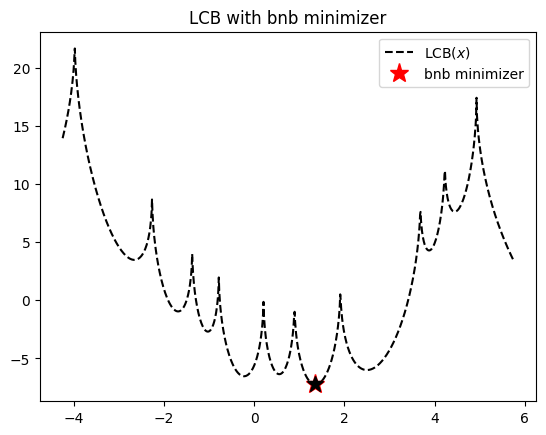

In [10]:
y_star = acqf.evaluate(xstar)
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
ystar_true = acqf.evaluate(xstar_true)
#print(xstar_true)
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
plt.plot(xstar_true, ystar_true, "k*", markersize=12)
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()


In [11]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'opt_solver': "SLSQP"    
}

In [12]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 3
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: SLSQP
hiopbbpy Internal optimization solver options: {'maxiter': 200}
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Logger level: INFO
hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 1.9883e-02 
hiopbbpy Best CONSTRAINED objective from 10 feasible initial samples: 1.9883e-02
hiopbbpy *****************************
hiopbbpy Iteration 1/3
hiopbbpy In batch 1/1
hiopbbpy Start finding the best sampling point:


=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -51.55759043161523
Initial acquisition upper bound: -5.189081699682497

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-51.55759043161523, U=-5.189081699682497
Current best feasible value (LUB): -5.189081699682497
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-34.257741324566574, U=-0.881580876797452
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-34.665279040939524, U=-2.0939713311986177
Queue size: 2 | LB=-34.665279040939524 | LUB=-5.189081699682497 | Gap<=29.476197341257027

--- BnB Iteration 2 ---
Node bounds: l=[0.75], u=[5.75]
Node acquisition bounds: L=-34.665279040939524, U=-2.0939713311986177
Current best feasible value (LUB): -5.189081699682497
  Branching to child: l=[0.75], u=[3.25]
  Child acquisition bounds: L=-25.76038337427

  Child acquisition bounds: L=-7.303704439465876, U=-5.078856256647844
Queue size: 20 | LB=-9.412955476714428 | LUB=-7.235623749317466 | Gap<=2.177331727396962

--- BnB Iteration 23 ---
Node bounds: l=[-1.125], u=[-0.5]
Node acquisition bounds: L=-9.412955476714428, U=-0.0006601787513296209
Current best feasible value (LUB): -7.235623749317466
  Branching to child: l=[-1.125], u=[-0.8125]
  Child acquisition bounds: L=-6.775319933298362, U=-2.5525709814428748
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.8125], u=[-0.5]
  Child acquisition bounds: L=-7.511406755142849, U=-3.2052679187184925
Queue size: 20 | LB=-9.118170992056934 | LUB=-7.235623749317466 | Gap<=1.8825472427394674

--- BnB Iteration 24 ---
Node bounds: l=[2.3125], u=[2.625]
Node acquisition bounds: L=-9.118170992056934, U=-5.992275807540654
Current best feasible value (LUB): -7.235623749317466
  Branching to child: l=[2.3125], u=[2.46875]
  Child acquisition bounds: L=-7.5494694873771175, U=-5.90417813753838

  Child acquisition bounds: L=-7.441209984140568, U=-7.201326839639801
  Branching to child: l=[1.31640625], u=[1.3359375]
  Child acquisition bounds: L=-7.4646715630696905, U=-7.225875598577687
Queue size: 25 | LB=-7.69064070439857 | LUB=-7.240472126488837 | Gap<=0.4501685779097331

--- BnB Iteration 47 ---
Node bounds: l=[1.375], u=[1.4140625]
Node acquisition bounds: L=-7.69064070439857, U=-7.219229058883007
Current best feasible value (LUB): -7.240472126488837
  Branching to child: l=[1.375], u=[1.39453125]
  Child acquisition bounds: L=-7.465941593349369, U=-7.228865939119778
  Branching to child: l=[1.39453125], u=[1.4140625]
  Child acquisition bounds: L=-7.443709075826979, U=-7.206716509050235
Queue size: 26 | LB=-7.623938235659362 | LUB=-7.240472126488837 | Gap<=0.38346610917052537

--- BnB Iteration 48 ---
Node bounds: l=[1.4140625], u=[1.453125]
Node acquisition bounds: L=-7.623938235659362, U=-7.151909937750883
Current best feasible value (LUB): -7.240472126488837
  Branchi

hiopbbpy   (mu, sigma) at new sample x: 0.6849227252406882, 2.6417982839098415 
hiopbbpy Best objective found in this iteration: 3.6659e-01 
hiopbbpy Training set size is now 11


...

  Child acquisition bounds: L=-5.672507891825865, U=-3.2690423864265625
  Branching to child: l=[-0.03125], u=[0.125]
  Child acquisition bounds: L=-6.185153137908131, U=-3.8874142716427045
Queue size: 19 | LB=-8.085789175100466 | LUB=-5.62215275948497 | Gap<=2.463636415615496

--- BnB Iteration 23 ---
Node bounds: l=[2.3125], u=[2.625]
Node acquisition bounds: L=-8.085789175100466, U=-4.984210764967777
Current best feasible value (LUB): -5.62215275948497
  Branching to child: l=[2.3125], u=[2.46875]
  Child acquisition bounds: L=-6.560892419081914, U=-4.937215657936356
  Branching to child: l=[2.46875], u=[2.625]
  Child acquisition bounds: L=-6.495966365239001, U=-4.942274412839777
Queue size: 20 | LB=-7.975227957980315 | LUB=-5.62215275948497 | Gap<=2.353075198495345

--- BnB Iteration 24 ---
Node bounds: l=[0.125], u=[0.4375]
Node acquisition bounds: L=-7.975227957980315, U=-3.41836417249321
Current best feasible value (LUB): -5.62215275948497
  Branching to child: l=[0.125], u=[0.

  Child acquisition bounds: L=-5.45187513555224, U=-4.3473035732542264
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.609375], u=[1.6875]
  Child acquisition bounds: L=-5.421195663719688, U=-4.332472158818007
  Child pruned: L ≥ LUB + eps.
Queue size: 22 | LB=-6.495966365239001 | LUB=-5.6580259260929235 | Gap<=0.8379404391460774

--- BnB Iteration 43 ---
Node bounds: l=[2.46875], u=[2.625]
Node acquisition bounds: L=-6.495966365239001, U=-4.942274412839777
Current best feasible value (LUB): -5.6580259260929235
  Branching to child: l=[2.46875], u=[2.546875]
  Child acquisition bounds: L=-5.765968407248403, U=-4.9737458365221725
  Branching to child: l=[2.546875], u=[2.625]
  Child acquisition bounds: L=-5.669922394747513, U=-4.8907278769199
Queue size: 23 | LB=-6.2729329867771995 | LUB=-5.6580259260929235 | Gap<=0.6149070606842759

--- BnB Iteration 44 ---
Node bounds: l=[2.15625], u=[2.3125]
Node acquisition bounds: L=-6.2729329867771995, U=-4.516697432780493
Current best f

  Child acquisition bounds: L=-5.088230878008558, U=-3.9007570725789114
  Child pruned: L ≥ LUB + eps.
Queue size: 24 | LB=-5.865106756659615 | LUB=-5.6580259260929235 | Gap<=0.20708083056669135

--- BnB Iteration 63 ---
Node bounds: l=[0.59375], u=[0.61328125]
Node acquisition bounds: L=-5.865106756659615, U=-5.601271771014873
Current best feasible value (LUB): -5.6580259260929235
  Branching to child: l=[0.59375], u=[0.60351562]
  Child acquisition bounds: L=-5.744604963436222, U=-5.612317099007042
  Branching to child: l=[0.60351562], u=[0.61328125]
  Child acquisition bounds: L=-5.721709847362973, U=-5.589008408703965
Queue size: 25 | LB=-5.859968827354013 | LUB=-5.6580259260929235 | Gap<=0.2019429012610896

--- BnB Iteration 64 ---
Node bounds: l=[0.49609375], u=[0.515625]
Node acquisition bounds: L=-5.859968827354013, U=-5.597188611359813
Current best feasible value (LUB): -5.6580259260929235
  Branching to child: l=[0.49609375], u=[0.50585938]
  Child acquisition bounds: L=-5.71

hiopbbpy   (mu, sigma) at new sample x: 0.17583488711280193, 1.9446202710685752 
hiopbbpy Best objective found in this iteration: 3.8147e-02 
hiopbbpy Training set size is now 13
hiopbbpy Current best objective: 3.8147e-02 (previous best: 3.6659e-01)
hiopbbpy Objective function improvement: 3.2845e-01
hiopbbpy ===================================
hiopbbpy Bayesian Optimization completed
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for BO iterations: 3
hiopbbpy Optimal at BO iteration: 3 
hiopbbpy Best value: 0.03814697265625
hiopbbpy ===================================


  Child acquisition bounds: L=-5.573977291319208, U=-5.439893887706576
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.46679688], u=[0.4765625]
  Child acquisition bounds: L=-5.617012325002158, U=-5.483546895662678
  Child pruned: L ≥ LUB + eps.
Queue size: 9 | LB=-5.722004690972311 | LUB=-5.6580259260929235 | Gap<=0.06397876487938703

--- BnB Iteration 85 ---
Node bounds: l=[0.3984375], u=[0.4375]
Node acquisition bounds: L=-5.722004690972311, U=-5.17768450739455
Current best feasible value (LUB): -5.6580259260929235
  Branching to child: l=[0.3984375], u=[0.41796875]
  Child acquisition bounds: L=-5.3809527328349755, U=-5.103818149778623
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.41796875], u=[0.4375]
  Child acquisition bounds: L=-5.51832762065733, U=-5.24565552263628
  Child pruned: L ≥ LUB + eps.
Queue size: 8 | LB=-5.721709847362973 | LUB=-5.6580259260929235 | Gap<=0.06368392127004974

--- BnB Iteration 86 ---
Node bounds: l=[0.60351562], u=[0.61328125]
N

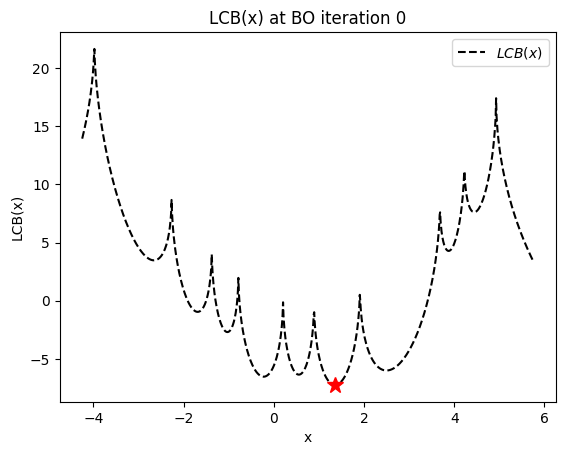

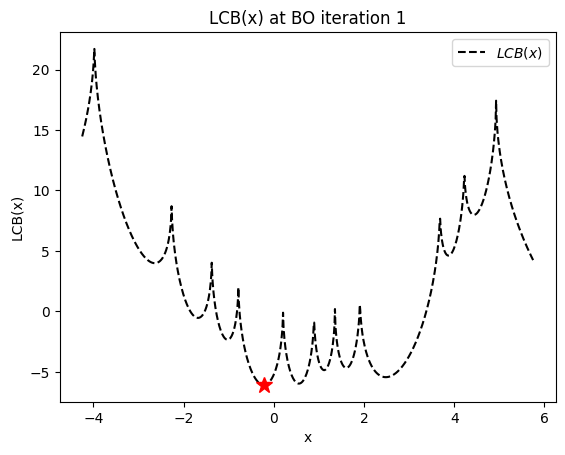

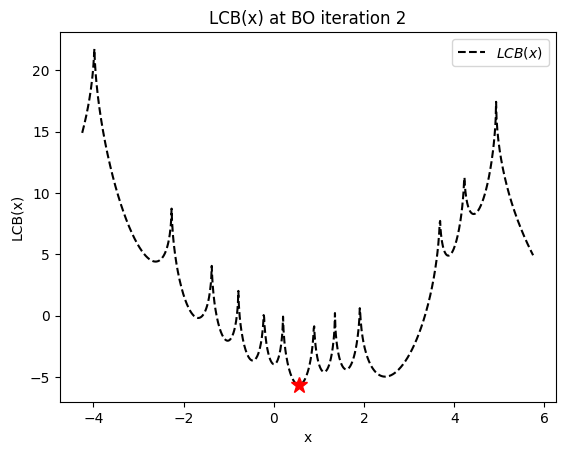

In [14]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    #plt.plot(X, muX, "-.", label=r'$\mu(x)$')
    #plt.plot(X, sigmaX, label=r'$\sigma(x)$')
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    